The data exploration of Ad exchange data is performed in this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_cpc2 = pd.read_csv(r'..\Dataset\realAdExchange\exchange-2_cpc_results.csv')
df_cpm2 = pd.read_csv(r'..\Dataset\realAdExchange\exchange-2_cpm_results.csv')
df_cpc2.info()
print("\n\n")
df_cpm2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1624 entries, 0 to 1623
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  1624 non-null   object 
 1   value      1624 non-null   float64
dtypes: float64(1), object(1)
memory usage: 25.5+ KB



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1624 entries, 0 to 1623
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  1624 non-null   object 
 1   value      1624 non-null   float64
dtypes: float64(1), object(1)
memory usage: 25.5+ KB


In [3]:
df_cpc2['timestamp'] = pd.to_datetime(df_cpc2['timestamp'])
df_cpm2['timestamp'] = pd.to_datetime(df_cpm2['timestamp'])

df_cpc2 = df_cpc2.rename(columns={'value': 'cpc'})
df_cpm2 = df_cpm2.rename(columns={'value': 'cpm'})

print(df_cpc2.describe())
print(df_cpm2.describe())

                           timestamp          cpc
count                           1624  1624.000000
mean   2011-08-03 22:58:10.162561024     0.101823
min              2011-07-01 00:00:01     0.026843
25%              2011-07-17 21:45:01     0.076633
50%              2011-08-03 20:30:01     0.100833
75%              2011-08-20 22:15:01     0.123618
max              2011-09-07 15:00:01     0.226598
std                              NaN     0.033729
                           timestamp          cpm
count                           1624  1624.000000
mean   2011-08-03 22:58:10.162561024     0.336523
min              2011-07-01 00:00:01     0.000385
25%              2011-07-17 21:45:01     0.208210
50%              2011-08-03 20:30:01     0.295056
75%              2011-08-20 22:15:01     0.456151
max              2011-09-07 15:00:01     1.051442
std                              NaN     0.162187


+ CPC values are tightly clustered (low std dev), suggesting stable cost per click.

+ CPM is more volatile (higher std dev), indicating fluctuations in cost per mille.

+ CPC and CPM both peak around early September.


In [4]:
df2 = pd.merge(df_cpc2, df_cpm2, on='timestamp', how='outer')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1626 entries, 0 to 1625
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1626 non-null   datetime64[ns]
 1   cpc        1626 non-null   float64       
 2   cpm        1626 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 38.2 KB


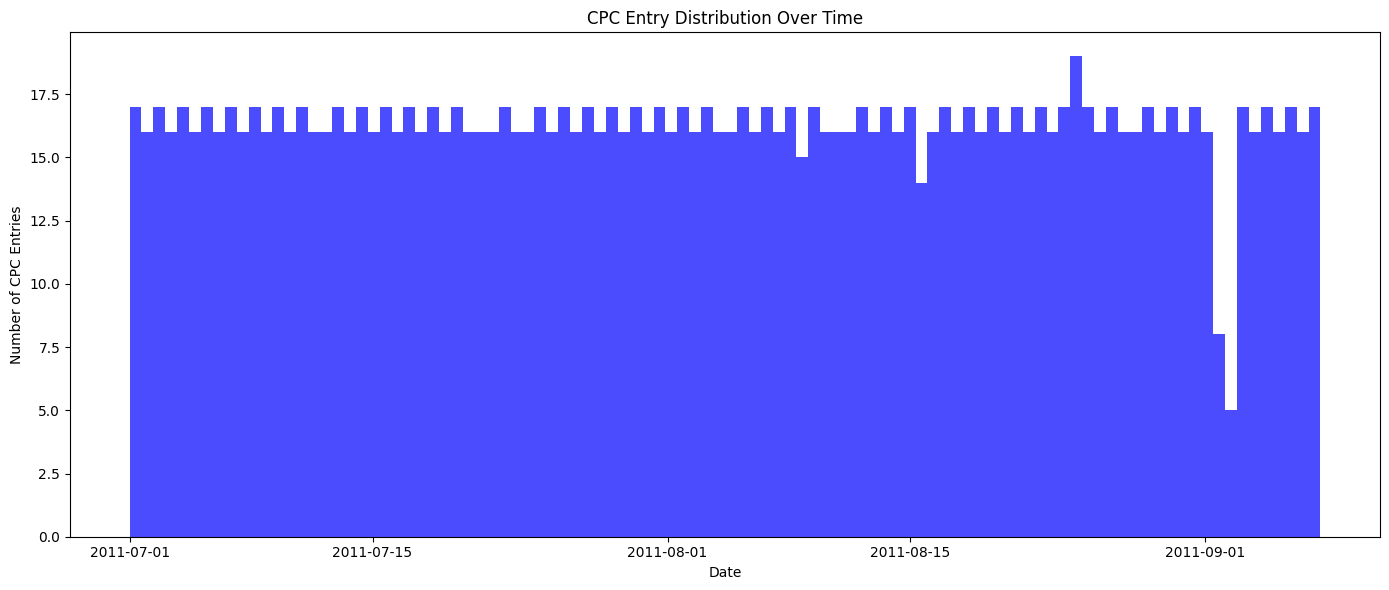

In [5]:
plt.figure(figsize=(14, 6))
plt.hist(df2['timestamp'], bins=100, color='blue', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Number of CPC Entries')
plt.title('CPC Entry Distribution Over Time')

plt.tight_layout()
plt.show()

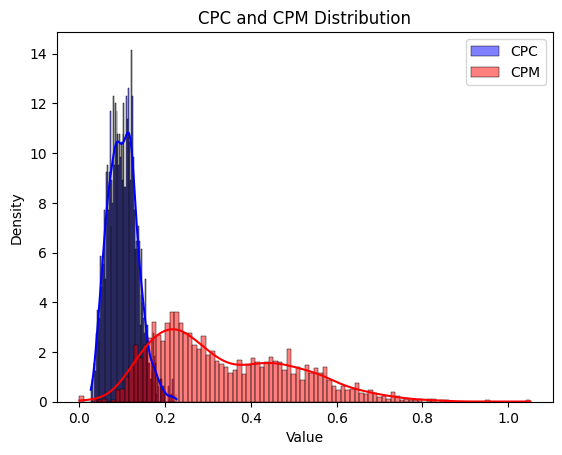

In [6]:
sns.histplot(data=df2, x='cpc', color='blue', label='CPC', kde=True, stat='density', bins=100)
sns.histplot(data=df2, x='cpm', color='red', label='CPM', kde=True, stat='density', bins=100, legend=True)
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('CPC and CPM Distribution')
plt.legend();

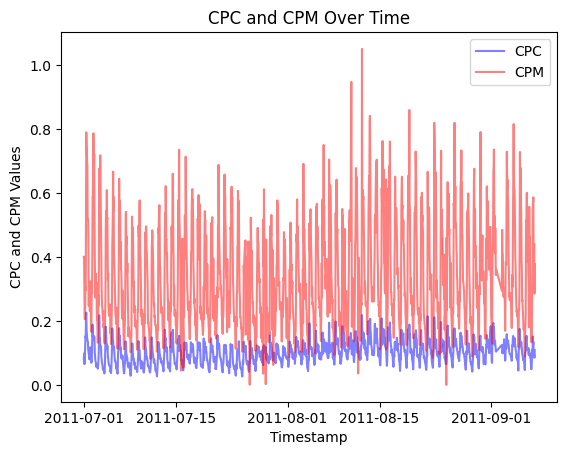

In [7]:
sns.lineplot(x='timestamp', y='cpc', data=df2, color='blue', label='CPC', alpha=0.5)
sns.lineplot(x='timestamp', y='cpm', data=df2, color='red', label='CPM', alpha=0.5)
plt.xlabel('Timestamp')
plt.ylabel('CPC and CPM Values')
plt.title('CPC and CPM Over Time')
plt.show()

+ The CPC/CPM record entries are mostly consistent over time other than in early september.
+ The CPM values are generally higher and more spread out than CPC values.
+ CPC values are predominantly very low, suggesting that clicks are often inexpensive. 
+ CPM values, on the other hand, show a broader range, which is expected as they represent cost per thousand impressions.
+ CPM line have sharp peaks and troughs, indicates that the cost per thousand impressions can fluctuate quite a bit.
+ The sudden drop of record entries in september can be seen in CPC/CPM line plot. 



In [8]:
def df_merge(path_a, path_b):
    #read the dataframes
    dfa = pd.read_csv(path_a)
    dfb = pd.read_csv(path_b)
    
    #convert timestamp to datetime
    dfa['timestamp'] = pd.to_datetime(dfa['timestamp'])
    dfb['timestamp'] = pd.to_datetime(dfb['timestamp'])
    
    #rename columns and merge
    dfa = dfa.rename(columns={'value': 'cpc'})
    dfb = dfb.rename(columns={'value': 'cpm'})
    df = pd.merge(dfa, dfb, on='timestamp', how='outer')
    
    return df

In [9]:
path1 = r'..\Dataset\realAdExchange\exchange-3_cpc_results.csv'
path2 = r'..\Dataset\realAdExchange\exchange-3_cpm_results.csv'
df3 = df_merge(path1, path2)
df3.describe()

,timestamp,cpc,cpm
count,1538,1538.000000,1538.000000
mean,2011-08-04 04:37:19.881664256,0.137259,0.772790
min,2011-07-01 00:15:01,0.038899,0.320650
25%,2011-07-18 04:30:01,0.097923,0.562521
50%,2011-08-04 05:45:01,0.118184,0.695304
75%,2011-08-21 02:00:01,0.153230,0.895622
max,2011-09-07 14:15:01,1.034000,5.497540
std,NaN,0.075671,0.337081


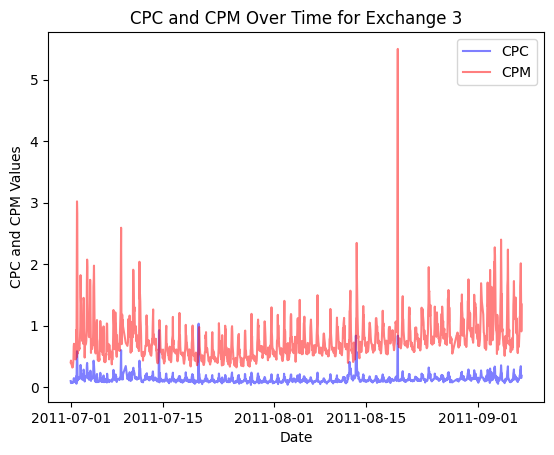

In [10]:
sns.lineplot(x='timestamp', y='cpc', data=df3, color='blue', label='CPC', alpha=0.5)
sns.lineplot(x='timestamp', y='cpm', data=df3, color='red', label='CPM', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('CPC and CPM Values')
plt.title('CPC and CPM Over Time for Exchange 3')
plt.legend();

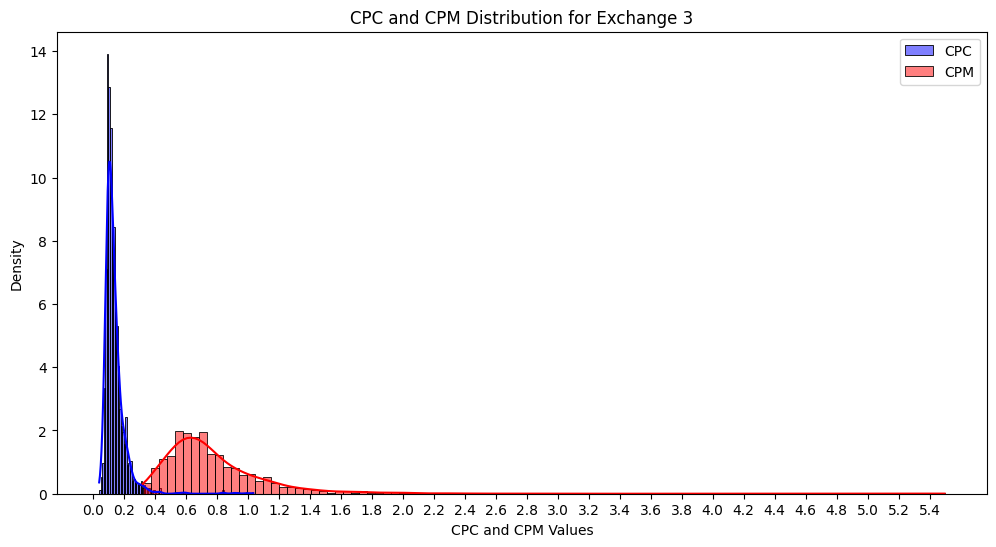

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df3, x='cpc', color='blue', label='CPC', kde=True, stat='density', bins=100)
sns.histplot(data=df3, x='cpm', color='red', label='CPM', kde=True, stat='density', bins=100)
plt.xlabel('CPC and CPM Values')
plt.ylabel('Density')
plt.xticks(np.arange(0, df3['cpm'].max(), 0.2))
plt.title('CPC and CPM Distribution for Exchange 3')
plt.legend();

+ The mode of CPC Values for exchange 3 is higher than exchange 2, while exchange 3 CPC is more spread out.
+ CPM for exchange 3 is highly spreaded and spikes, indicating of outliers and anomaly. 
+ CPM and CPC can exhibit independent spiking behavior.

In [12]:
path1 = r'..\Dataset\realAdExchange\exchange-4_cpc_results.csv'
path2 = r'..\Dataset\realAdExchange\exchange-4_cpm_results.csv'
df4 = df_merge(path1, path2)
df4.describe()

,timestamp,cpc,cpm
count,1643,1643.000000,1643.000000
mean,2011-08-04 08:00:31.127814656,0.086439,0.533830
min,2011-07-01 00:15:01,0.023884,0.121520
25%,2011-07-18 04:45:01,0.055185,0.360400
50%,2011-08-04 09:15:01,0.072820,0.467618
75%,2011-08-21 11:45:01,0.095459,0.583870
max,2011-09-07 14:15:01,3.126852,16.438200
std,NaN,0.128977,0.747022


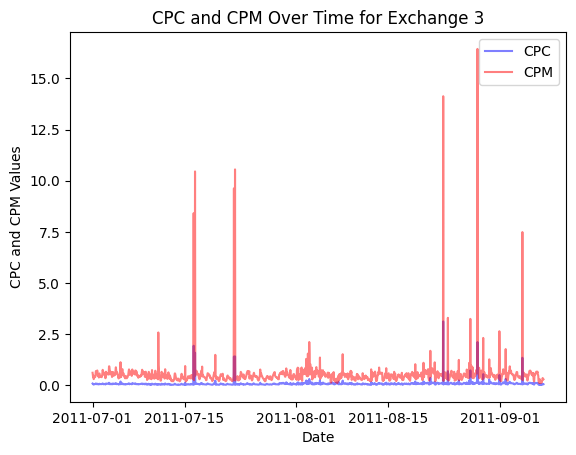

In [13]:
sns.lineplot(x='timestamp', y='cpc', data=df4, color='blue', label='CPC', alpha=0.5)
sns.lineplot(x='timestamp', y='cpm', data=df4, color='red', label='CPM', alpha=0.5)
plt.xlabel('Date')
plt.ylabel('CPC and CPM Values')
plt.title('CPC and CPM Over Time for Exchange 3')
plt.legend();

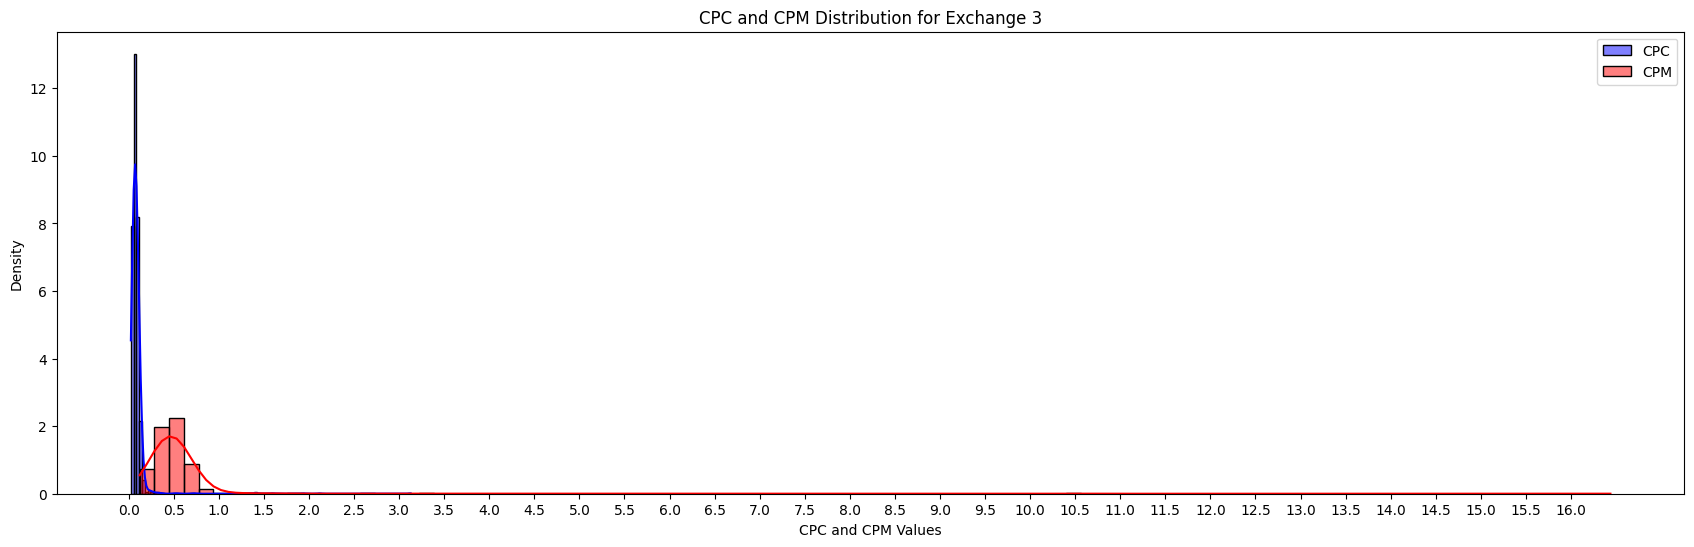

In [14]:
plt.figure(figsize=(21, 6))
sns.histplot(data=df4, x='cpc', color='blue', label='CPC', kde=True, stat='density', bins=100)
sns.histplot(data=df4, x='cpm', color='red', label='CPM', kde=True, stat='density', bins=100)
plt.xlabel('CPC and CPM Values')
plt.ylabel('Density')
plt.xticks(np.arange(0, df4['cpm'].max(), 0.5))
plt.title('CPC and CPM Distribution for Exchange 3')
plt.legend();

+ CPM for exchange 4 is more spread out and have even larger spikes.
+ In exchange4 record, CPM and CPC spikes mostly coincide.


As per the dataset description on Kaggle, only one file is normal without anomalies. From the lineplot it appears the exchange-2 could be the normal clicks without anomalies.

## More Plots

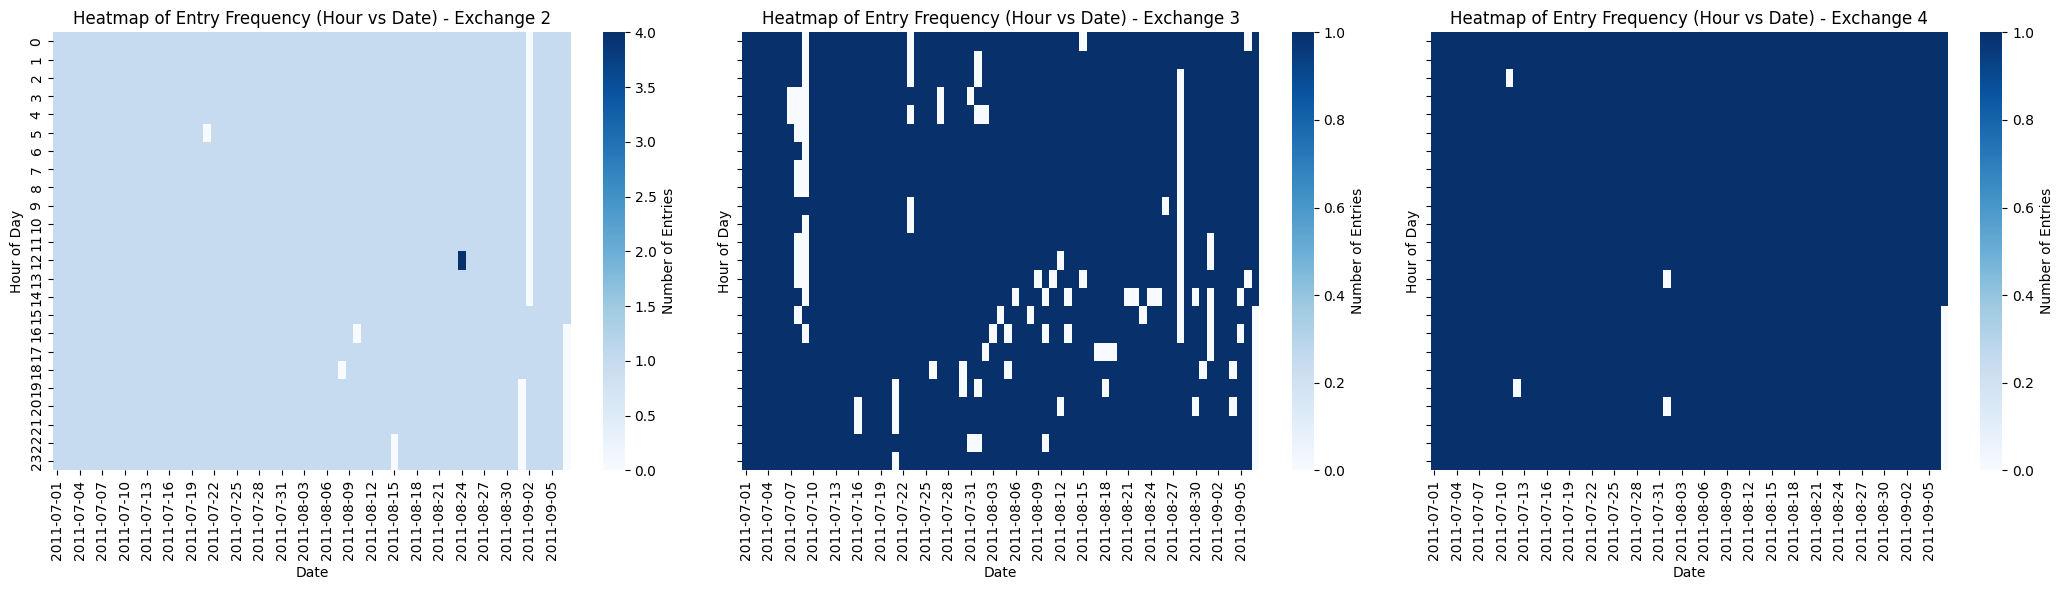

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for i, df in enumerate([df2, df3, df4]):
    df['date'] = df['timestamp'].dt.date
    df['hour'] = df['timestamp'].dt.hour
    
    # Group by date and hour, count entries
    heatmap_data = df.groupby(['date', 'hour']).size().unstack(fill_value=0)

    # Plot heatmap
    sns.heatmap(heatmap_data.T, cmap='Blues', cbar_kws={'label': 'Number of Entries'}, ax=axes[i])
    axes[i].set_title(f'Heatmap of Entry Frequency (Hour vs Date) - Exchange {i+2}')
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Hour of Day')

plt.tight_layout()
plt.show()


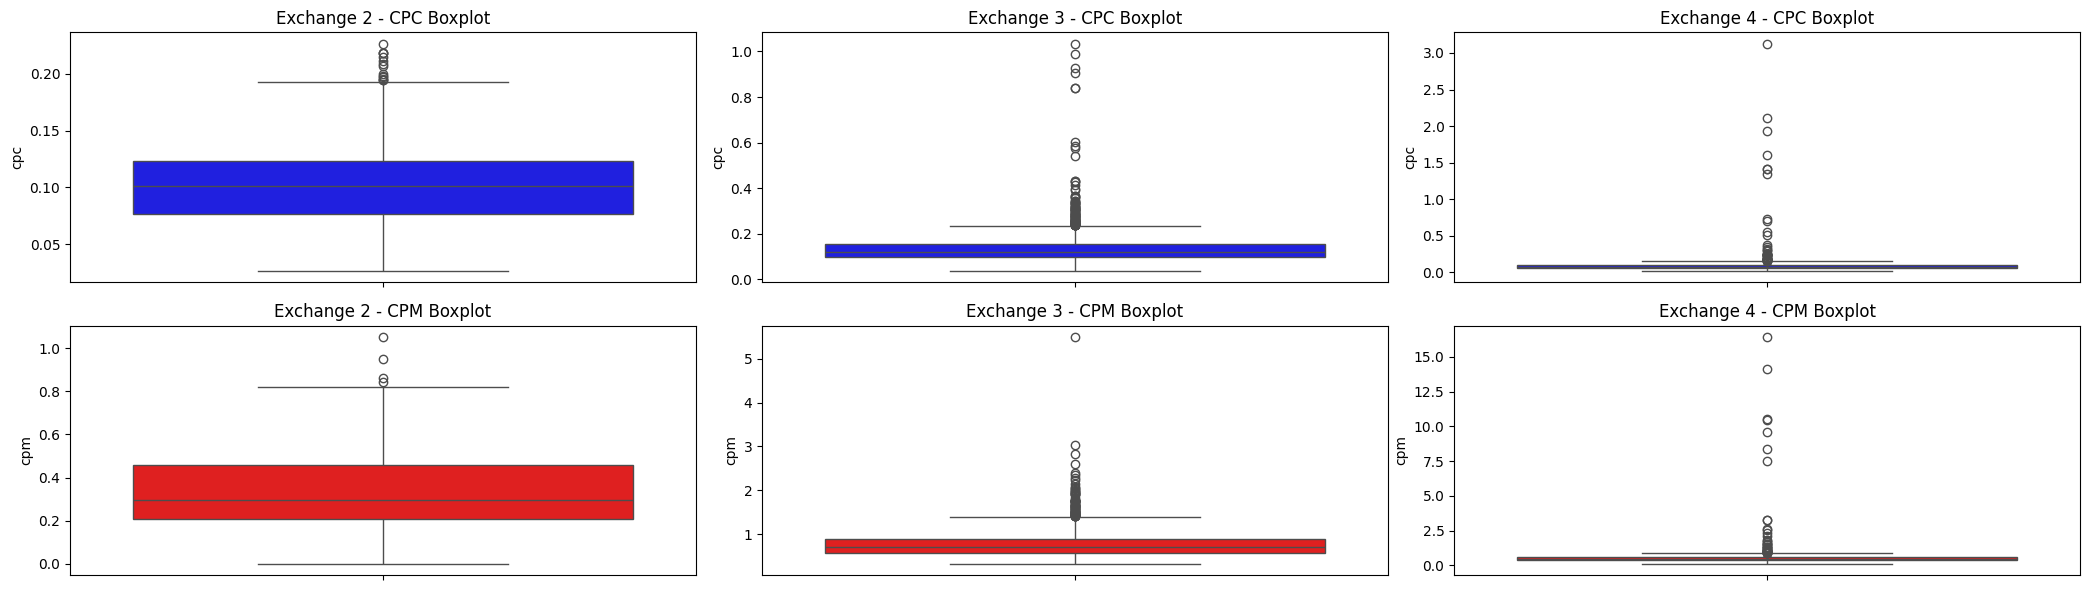

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(21, 6), sharey=False)

for i, df in enumerate([df2, df3, df4]):
    # boxplot
    sns.boxplot(y='cpc', data=df, color='blue', ax=axes[0][i])
    sns.boxplot(y='cpm', data=df, color='red', ax=axes[1][i])

    axes[0][i].set_title(f'Exchange {i + 2} - CPC Boxplot')
    axes[1][i].set_title(f'Exchange {i + 2} - CPM Boxplot')
    
plt.tight_layout()
plt.show()

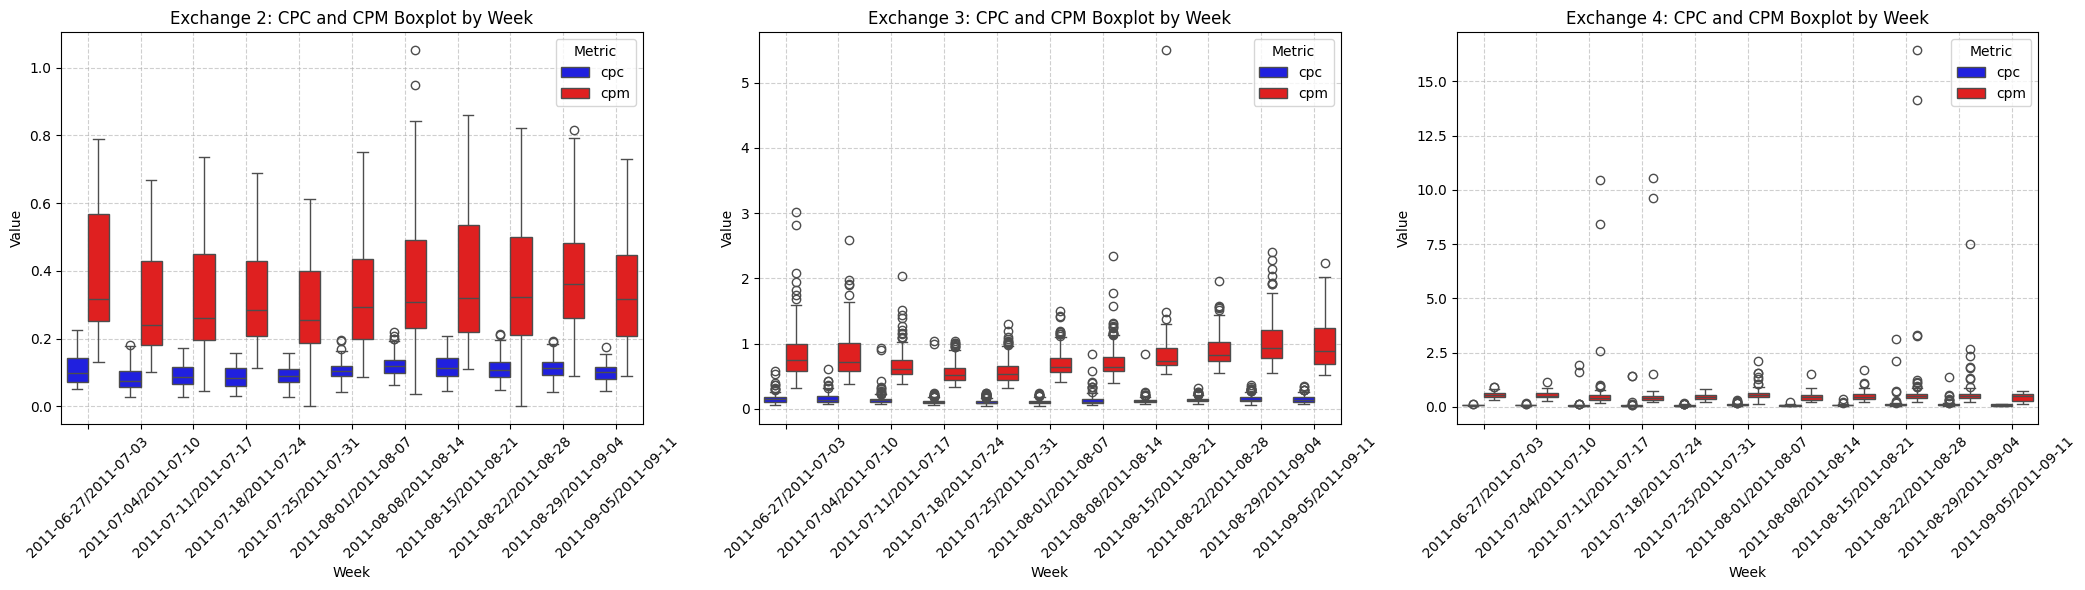

In [16]:
# Bin timestamps to weekly periods for cleaner boxplots
for df in [df2, df3, df4]:
    df['week'] = df['timestamp'].dt.to_period('W').astype(str)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=False)


for i, (df, ax) in enumerate(zip([df2, df3, df4], axes)):
    # Melt data to long format for seaborn boxplot
    df_melted = pd.melt(df, id_vars='week', value_vars=['cpc', 'cpm'],
                        var_name='Metric', value_name='Value')

    sns.boxplot(data=df_melted, x='week', y='Value', hue='Metric',
                ax=ax, palette={'cpc': 'blue', 'cpm': 'red'})

    ax.set_title(f'Exchange {i + 2}: CPC and CPM Boxplot by Week')
    ax.set_xlabel('Week')
    ax.set_ylabel('Value')
    ax.legend(title='Metric')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


+ Exchange 3 and 4 does not have more than 1 entry per hour, so the heatmap will not show much variation.
+ Exchange 2 (normal ads record) shows very outlier values compared to the other exchanges (Ads record with anomalies)

In [31]:
df2.describe()

,timestamp,cpc,cpm,hour
count,1626,1626.000000,1626.000000,1626.000000
mean,2011-08-03 23:34:33.324722688,0.101852,0.336644,11.457565
min,2011-07-01 00:00:01,0.026843,0.000385,0.000000
25%,2011-07-17 22:15:01,0.076684,0.208260,5.250000
50%,2011-08-03 21:30:01,0.100967,0.295370,11.000000
75%,2011-08-20 23:45:01,0.123625,0.456658,17.000000
max,2011-09-07 15:00:01,0.226598,1.051442,23.000000
std,NaN,0.033719,0.162127,6.901575


In [46]:
print(
    df2['timestamp'].is_monotonic_increasing and
    df3['timestamp'].is_monotonic_increasing and
    df4['timestamp'].is_monotonic_increasing
)

True


All the 3 exchange entries are in increasing order of timestamp, with few missing timestamps in between.

In [73]:
df2.head()

,timestamp,cpc,cpm,date,hour,week
0,2011-07-01 00:00:01,0.081965,0.401048,2011-07-01,0,2011-06-27/2011-07-03
1,2011-07-01 01:00:01,0.098972,0.392719,2011-07-01,1,2011-06-27/2011-07-03
2,2011-07-01 02:00:01,0.065314,0.309996,2011-07-01,2,2011-06-27/2011-07-03
3,2011-07-01 03:00:01,0.070663,0.212939,2011-07-01,3,2011-06-27/2011-07-03
4,2011-07-01 04:00:01,0.102490,0.205801,2011-07-01,4,2011-06-27/2011-07-03


In [85]:
df2[df2['timestamp'].duplicated()]

,timestamp,cpc,cpm,date,hour,week
1304,2011-08-24 12:00:01,0.131250,0.461745,2011-08-24,12,2011-08-22/2011-08-28
1305,2011-08-24 12:00:01,0.119453,0.408490,2011-08-24,12,2011-08-22/2011-08-28
1306,2011-08-24 12:00:01,0.119453,0.461745,2011-08-24,12,2011-08-22/2011-08-28


In [96]:
print(f'Exchange 2 timestamp, min: {df2['timestamp'].min()} and max: {df2['timestamp'].max()}') 
print(f'Exchange 3 timestamp, min: {df3['timestamp'].min()} and max: {df3['timestamp'].max()}') 
print(f'Exchange 4 timestamp, min: {df4['timestamp'].min()} and max: {df4['timestamp'].max()}')

Exchange 2 timestamp, min: 2011-07-01 00:00:01 and max: 2011-09-07 15:00:01
Exchange 3 timestamp, min: 2011-07-01 00:15:01 and max: 2011-09-07 14:15:01
Exchange 4 timestamp, min: 2011-07-01 00:15:01 and max: 2011-09-07 14:15:01


In [97]:
for e in df2.head():
    print(e)

timestamp
cpc
cpm
date
hour
week


In [91]:
df4.iloc[1300:1310, :]

,timestamp,cpc,cpm,date,hour,week
1300,2011-08-24 08:15:01,0.090153,0.392581,2011-08-24,8,2011-08-22/2011-08-28
1301,2011-08-24 09:15:01,0.104207,0.495107,2011-08-24,9,2011-08-22/2011-08-28
1302,2011-08-24 10:15:01,0.119424,0.546083,2011-08-24,10,2011-08-22/2011-08-28
1303,2011-08-24 11:15:01,0.128282,0.584732,2011-08-24,11,2011-08-22/2011-08-28
1304,2011-08-24 12:15:01,0.126096,0.627286,2011-08-24,12,2011-08-22/2011-08-28
1305,2011-08-24 13:15:01,0.111087,0.607119,2011-08-24,13,2011-08-22/2011-08-28
1306,2011-08-24 14:15:01,0.123632,0.715906,2011-08-24,14,2011-08-22/2011-08-28
1307,2011-08-24 15:15:01,0.104104,0.564072,2011-08-24,15,2011-08-22/2011-08-28
1308,2011-08-24 16:15:01,0.085488,0.480102,2011-08-24,16,2011-08-22/2011-08-28
1309,2011-08-24 17:15:01,0.077391,0.445944,2011-08-24,17,2011-08-22/2011-08-28


In [ ]:
(df2['timestamp'] - df2['timestamp'].min()).dt.total_seconds() / 3600

0          0.0
1          1.0
2          2.0
3          3.0
4          4.0
         ...  
1621    1643.0
1622    1644.0
1623    1645.0
1624    1646.0
1625    1647.0
Name: timestamp, Length: 1626, dtype: float64